# Stochastic Optimization

## Exercise on Control
Benoît Keryer
Quentin Chevaux

<a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" align="left" src="https://i.creativecommons.org/l/by-sa/4.0/80x15.png" /></a>&nbsp;| Dennis G. Wilson | <a href="https://supaerodatascience.github.io/stochastic/">https://supaerodatascience.github.io/stochastic/</a>

Today you'll explore advanced SGD methods (momentum, Adam) and compare them with gradient-free approaches on a robotic arm control problem. You'll also learn automatic differentiation with JAX.

In [62]:
# Setup and Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import jax
import jax.numpy as jnp
from jax import grad, jit
from typing import Tuple, List, Callable
import time

# Set random seeds for reproducibility
np.random.seed(42)

# Enable JAX to run on CPU (for consistent behavior across platforms)
jax.config.update('jax_platform_name', 'cpu')

print("Setup complete! JAX version:", jax.__version__)
print("NumPy version:", np.__version__)

Setup complete! JAX version: 0.8.0
NumPy version: 2.3.3


# Exploring the Robot Arm
Run the provided visualization to understand the 2-joint planar arm. Experiment with different joint angles. We will experiment with two different libraries for this robot arm: numpy and [jax](docs.jax.dev/en/latest/index.html). Jax will enable easier gradient calculations through [automatic differentiation](https://huggingface.co/blog/andmholm/what-is-automatic-differentiation). For now, understand and explore this 2-joint robot arm which uses two angles to calculate the end position of the arm.

In [63]:
def forward_kinematics_numpy(theta: np.ndarray, lengths: np.ndarray) -> np.ndarray:
    """
    Compute end-effector position for a 2-joint planar arm.
    
    Parameters:
    -----------
    theta : np.ndarray, shape (2,)
        Joint angles [theta1, theta2] in radians
    lengths : np.ndarray, shape (2,)
        Link lengths [L1, L2]
    
    Returns:
    --------
    position : np.ndarray, shape (2,)
        End-effector position [x, y]
    """
    theta1, theta2 = theta
    L1, L2 = lengths
    
    # First joint position
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    # End-effector position
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return np.array([x2, y2])

In [64]:
# JAX version (for automatic differentiation)
def forward_kinematics_jax(theta: jnp.ndarray, lengths: jnp.ndarray) -> jnp.ndarray:
    """
    Compute end-effector position for a 2-joint planar arm (JAX version).
    
    Parameters:
    -----------
    theta : jnp.ndarray, shape (2,)
        Joint angles [theta1, theta2] in radians
    lengths : jnp.ndarray, shape (2,)
        Link lengths [L1, L2]
    
    Returns:
    --------
    position : jnp.ndarray, shape (2,)
        End-effector position [x, y]
    """
    theta1, theta2 = theta
    L1, L2 = lengths
    
    # First joint position
    x1 = L1 * jnp.cos(theta1)
    y1 = L1 * jnp.sin(theta1)
    
    # End-effector position
    x2 = x1 + L2 * jnp.cos(theta1 + theta2)
    y2 = y1 + L2 * jnp.sin(theta1 + theta2)
    
    return jnp.array([x2, y2])

In [65]:
# Get all joint positions for visualization
def get_arm_points(theta: np.ndarray, lengths: np.ndarray) -> np.ndarray:
    """
    Get positions of all joints for visualization.
    
    Returns:
    --------
    points : np.ndarray, shape (3, 2)
        Positions of [base, joint1, end-effector]
    """
    theta1, theta2 = theta
    L1, L2 = lengths
    
    # Base at origin
    p0 = np.array([0.0, 0.0])
    
    # First joint
    p1 = np.array([L1 * np.cos(theta1), L1 * np.sin(theta1)])
    
    # End-effector
    p2 = p1 + np.array([L2 * np.cos(theta1 + theta2), 
                        L2 * np.sin(theta1 + theta2)])
    
    return np.array([p0, p1, p2])

In [66]:
# Test the implementations
print("Testing forward kinematics...")
test_theta = np.array([np.pi/4, np.pi/4])
test_lengths = np.array([1.0, 1.0])

pos_numpy = forward_kinematics_numpy(test_theta, test_lengths)
pos_jax = forward_kinematics_jax(test_theta, test_lengths)

print(f"NumPy result: {pos_numpy}")
print(f"JAX result: {pos_jax}")
print(f"Match: {np.allclose(pos_numpy, np.array(pos_jax))}")

Testing forward kinematics...
NumPy result: [0.70710678 1.70710678]
JAX result: [0.7071067 1.7071068]
Match: True


In [67]:
# Visualization Utilities
def plot_arm(theta: np.ndarray, lengths: np.ndarray, 
             target: np.ndarray = None, obstacles: List = None,
             ax=None, title: str = "Robot Arm"):
    """
    Plot the robot arm configuration.
    
    Parameters:
    -----------
    theta : np.ndarray
        Joint angles
    lengths : np.ndarray
        Link lengths
    target : np.ndarray, optional
        Target position to visualize
    obstacles : List of tuples, optional
        List of (x, y, radius) for circular obstacles
    ax : matplotlib axis, optional
        Axis to plot on
    title : str
        Plot title
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    # Get arm points
    points = get_arm_points(theta, lengths)
    
    # Plot arm links
    ax.plot(points[:, 0], points[:, 1], 'o-', linewidth=3, 
            markersize=8, label='Arm', color='blue')
    
    # Plot base
    ax.plot(0, 0, 'ks', markersize=12, label='Base')
    
    # Plot end-effector
    ax.plot(points[-1, 0], points[-1, 1], 'ro', 
            markersize=10, label='End-effector')
    
    # Plot target if provided
    if target is not None:
        ax.plot(target[0], target[1], 'g*', 
                markersize=15, label='Target')
    
    # Plot obstacles if provided
    if obstacles is not None:
        for obs in obstacles:
            circle = Circle((obs[0], obs[1]), obs[2], 
                          color='red', alpha=0.3, label='Obstacle')
            ax.add_patch(circle)
    
    # Set axis properties
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.legend()
    
    return ax

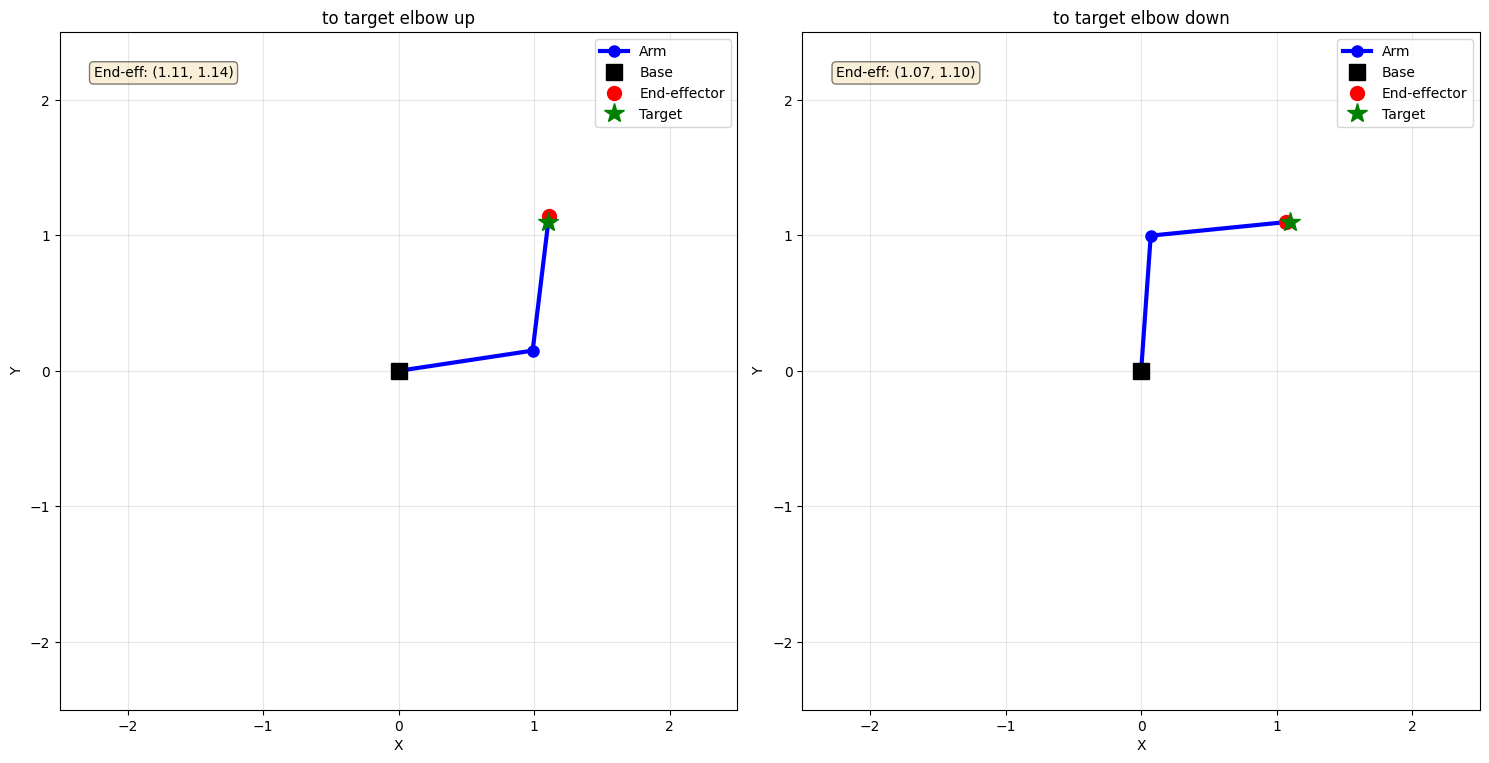

In [68]:
# Standard link lengths we'll use throughout
LENGTHS = np.array([1.0, 1.0])

# Example: Visualize different arm configurations
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes = axes.flatten()

# TODO: try more configurations
example_configs = [
    (np.array([0.15, 1.3]), "to target elbow up"),
    (np.array([1.5, -1.4]), "to target elbow down")
]

target = np.array([1.1, 1.1])
for i, (theta, title) in enumerate(example_configs):
    plot_arm(theta, LENGTHS, target=target, ax=axes[i], title=title)
    end_eff = forward_kinematics_numpy(theta, LENGTHS)
    axes[i].text(0.05, 0.95, f'End-eff: ({end_eff[0]:.2f}, {end_eff[1]:.2f})',
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

<div class="alert alert-info">
Q1: The robot arm has multiple solutions to reach the same point (elbow-up vs elbow-down configurations). Using the provided forward_kinematics function, find two different joint angle configurations θ = [θ₁, θ₂] that place the end-effector at approximately (1.1, 1.1). What does this tell you about the optimization landscape?
</div>

## Q1 solution and answer here
En essayant plusieurs valeurs manuellement, on trouve que les angles (0.15, 1.3) pour le coude en haut 
et (1.5, -1.4) pour le coude en bas permettent d'atteindre approximativement la cible (1.1, 1.1).

Ce paysage d'optimisation est donc non convexe puisqu'il existe plusieurs configurations optimales.

Pour visualiser, faire tourner la cellule de code précédente.

## Part 1: Automatic Differentiation

Instead of guessing at the angles for a target, we will calculate them exactly. Use the provided JAX implementation to compute gradients of the loss function with respect to joint angles.

In [69]:
# Loss Functions
def loss_target_reaching(theta: jnp.ndarray, lengths: jnp.ndarray, 
                        target: jnp.ndarray) -> float:
    """
    Loss for reaching a target position.
    
    L = ||end_effector(theta) - target||^2
    
    Parameters:
    -----------
    theta : jnp.ndarray, shape (2,)
        Joint angles
    lengths : jnp.ndarray, shape (2,)
        Link lengths
    target : jnp.ndarray, shape (2,)
        Target position
    
    Returns:
    --------
    loss : float
        Squared distance to target
    """
    end_effector = forward_kinematics_jax(theta, lengths)
    return jnp.sum((end_effector - target) ** 2)

In [70]:
# Create JIT-compiled versions for speed
loss_target_reaching_jit = jit(loss_target_reaching)
print(loss_target_reaching)
print(loss_target_reaching_jit)

<function loss_target_reaching at 0x75f6e3830f40>
<PjitFunction of <function loss_target_reaching at 0x75f6e3830f40>>


In [71]:
# Create gradient functions
grad_loss_target = jit(grad(loss_target_reaching, argnums=0))

In [72]:
# Test the loss functions
print("Testing loss functions...")
test_theta = jnp.array([0.5, 0.5])
test_lengths = jnp.array([1.0, 1.0])
test_target = jnp.array([1.0, 1.0])

loss_val = loss_target_reaching(test_theta, test_lengths, test_target)
print(f"Loss value: {loss_val:.4f}")

grad_val = grad_loss_target(test_theta, test_lengths, test_target)
print(f"Gradient: {grad_val}")

Testing loss functions...
Loss value: 0.2776
Gradient: [-0.19397666 -0.35651368]


<div class="alert alert-info">
Q2: Compute the gradient using JAX autodiff at $θ=[π/6, π/4]$
Then verify it matches a manual finite-difference approximation:

For finite differences, use:
  $∂L/∂θᵢ ≈ (L(θ + h*eᵢ) - L(θ - h*eᵢ)) / (2h)$
  where $eᵢ$ is the i-th unit vector and $h = 1e-5$
</div>

In [73]:
test_theta = jnp.array([np.pi/6, np.pi/4])
test_lengths = jnp.array([1.0, 1.0])
test_target = jnp.array([1.0, 1.0])
gradient_jax = grad_loss_target(test_theta, test_lengths, test_target)
print("loss function gradient (jax):",[float(g) for g in gradient_jax])

h = 1e-5
gradient_fd = [(loss_target_reaching(test_theta + jnp.array([h, 0.0]), test_lengths, test_target) - 
               loss_target_reaching(test_theta - jnp.array([h, 0.0]), test_lengths, test_target) )/ (2 * h),
               (loss_target_reaching(test_theta + jnp.array([0.0, h]), test_lengths, test_target) - 
               loss_target_reaching(test_theta - jnp.array([0.0, h]), test_lengths, test_target)) / (2 * h)]
print("loss function gradient (fd):",[float(g) for g in gradient_fd])

# On observe que les deux gradients sont très proches.

loss function gradient (jax): [0.6821628212928772, 6.261912943728021e-08]
loss function gradient (fd): [0.6839632987976074, -0.0014901161193847656]


<div class="alert alert-info">
Q3: Compare the computational time of evaluating the gradient using JAX autodiff versus evaluating just the forward pass (loss calculation only). Run each 1000 times and report the ratio. What does this tell you about the computational overhead of automatic differentiation?</div>

In [74]:
start_time_jax = time.perf_counter()
for i in range(1000):
    _ = grad_loss_target(test_theta, test_lengths, test_target)

end_time_jax = time.perf_counter()

print(f"Temps de calcul jax : {end_time_jax - start_time_jax:.6f} s")

start_time_loss = time.perf_counter()
for i in range(1000):
    _ = loss_target_reaching(test_theta, test_lengths, test_target)

end_time_loss = time.perf_counter()

print(f"Temps de calcul forward pass : {end_time_loss - start_time_loss:.6f} s")
print("ratio jax / forward pass :", (end_time_jax - start_time_jax) / (end_time_loss - start_time_loss))

Temps de calcul jax : 0.017431 s


Temps de calcul forward pass : 0.967772 s
ratio jax / forward pass : 0.01801181254106878


Q3

En utilisant le forward pass non compilé, on obtient que jax est environ 20 fois plus rapide.
En utilisant la version compilée avec jit, les temps d'exécution sont similaires.

## Part 2: Gradient Descent

Gradient Descent (GD) is the foundational optimization algorithm that iteratively moves parameters in the direction of steepest descent:
$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$

While conceptually simple, GD can be sensitive to the learning rate $η$ and may struggle with saddle points or narrow valleys in the loss landscape where the gradient direction changes rapidly.

For this exercise, implement basic gradient descent to move the robot arm to a target position.

In [75]:
def gradient_descent(theta_init: np.ndarray, 
                     target: np.ndarray,
                     lengths: np.ndarray,
                     learning_rate: float = 0.01,
                     n_iterations: int = 500,
                     lambda_obs: float = 10.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Convert to JAX arrays
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    

    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)
    grad_fn = grad_loss_target

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))
    
    # Initial values
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))
    
    # Optimization loop
    for i in range(n_iterations):
        # Compute gradient
        gradient = grad_fn(theta, lengths_jax, target_jax)
        
        # Update theta using gradient descent rule
        theta = theta - learning_rate * gradient
        
        # Store history
        theta_history[i + 1] = np.array(theta)        
        loss_history[i + 1] = float(loss_fn(theta))        
        ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))
    
    return theta_history, loss_history, ee_trajectory

<div class="alert alert-info">
Q4: Run GD with learning rates $η = [0.001, 0.01, 0.1, 0.5, 1.0]$ for 500 iterations each, starting from $θ₀ = [0.1, 0.1]$ targeting (0.5, 1.5). Plot the loss curves. At what learning rate do you observe divergence? Explain what's happening in terms of the gradient descent update rule.
</div>

Learning rate: 0.001
Learning rate: 0.01
Learning rate: 0.1
Learning rate: 0.5
Learning rate: 1.0


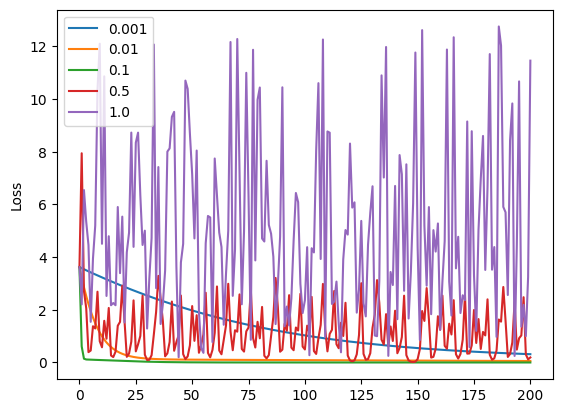

In [76]:
theta_target = jnp.array([0.5, 1.5]) 
 
for l in [0.001, 0.01, 0.1, 0.5, 1.]:
    print(f"Learning rate: {l}")
    theta_0 = np.array([0.1, 0.1])
    theta_hist, loss_hist, ee_traj = gradient_descent(theta_0, theta_target, LENGTHS, learning_rate=l, n_iterations=200)
      
    plt.plot(loss_hist)
    plt.ylabel('Loss')
    plt.legend([0.001, 0.01, 0.1, 0.5, 1.])
    

Q4

On observe une divergence pour un learning_rate supérieur ou égal à 0.5. Dans ces cas-là, le pas est trop élevé pour faire 
converger les angles, et ils oscillent indéfiniment d'une pente à l'autre.

<div class="alert alert-info">
Q5: For $η = 0.01$, plot the end-effector trajectory in 2D space (not the loss, but the actual path the end-effector takes). Does it take the most direct path to the target? Why or why not? (Hint: think about parameter space vs task space)
</div>

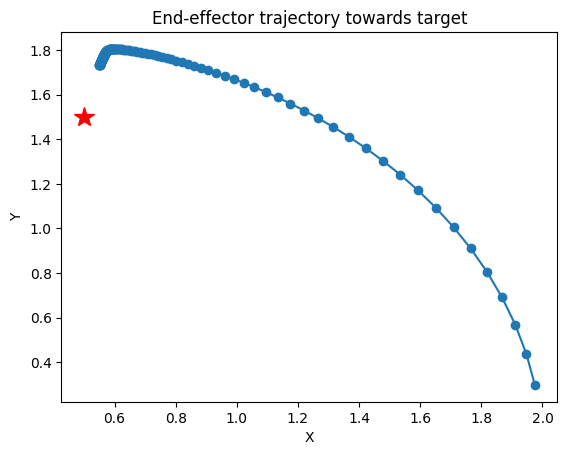

In [77]:
theta_hist, loss_hist, ee_traj = gradient_descent(theta_0, theta_target, LENGTHS, learning_rate=0.01, n_iterations=200)
plt.plot(ee_traj[:,0], ee_traj[:,1], 'o-')
plt.plot(theta_target[0], theta_target[1], 'r*', markersize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('End-effector trajectory towards target')
plt.show()

Q5

L'algorithme ne prend pas ici le chemin le plus direct vers l'objectif d'après la représentation cartésienne de l'espace. Cependant, cela est normal puisque l'algorithme travaille avec des angles liés entre eux, qui sont des arguments de fonctions trigonimétriques formant un espace non-linéaire.

## 2.2: SGD with Momentum

Momentum adds "inertia" to gradient descent by accumulating a velocity vector that combines the current gradient with previous gradients: $_t = \beta v_{t-1} + \nabla L(\theta_t)$
, then $\theta_{t+1} = \theta_t - \eta v_t$. This helps the optimizer build up speed in consistent directions and dampens oscillations in directions where gradients frequently change sign, allowing it to better navigate ravines and escape shallow local minima.


For this exercise, implement momentum-based gradient descent using the update rules:

$v_t = βv_{t-1} + ∇L(θ_t)$

$θ_{t+1} = θ_t - ηv_t$

<div class="alert alert-info">
Q6: Compare GD vs Momentum ($β=0.9$) on the same task ($η=0.01$, target (0.5, 1.5)). Plot both the loss curves and the end-effector trajectories side-by-side. Describe one specific, concrete difference in how the arm moves with momentum versus without.
</div>
<div class="alert alert-info">
Q7: Track and plot the magnitude of the velocity vector $||v_t||$ over iterations for the momentum optimizer. What happens to this magnitude as the arm approaches the target? Explain why this behavior occurs.
</div>

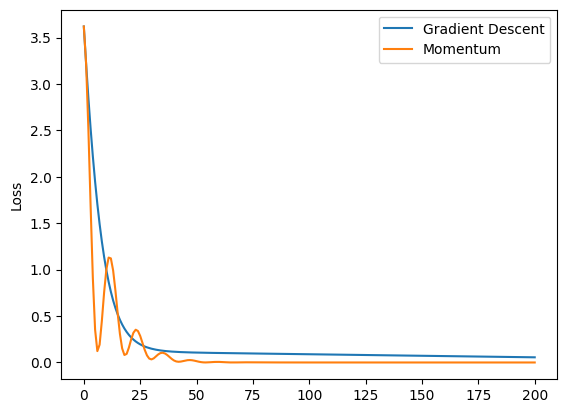

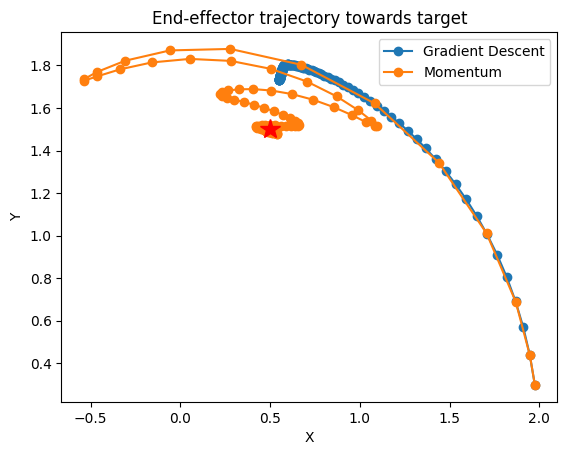

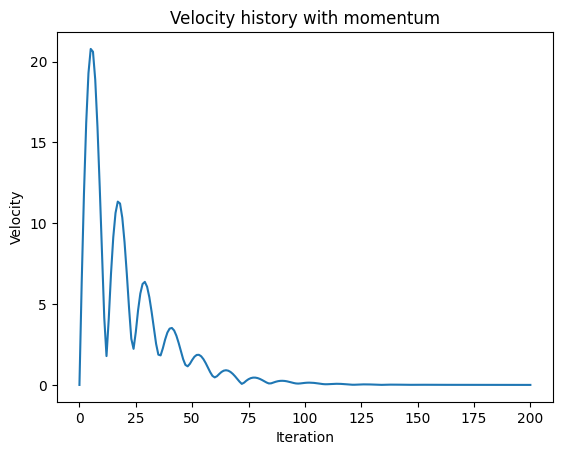

In [78]:
def momentum_gradient(theta_init, target, lengths, learning_rate=0.01, n_iterations=500, beta=0.9):
    # Convert to JAX arrays
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    

    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)
    grad_fn = grad_loss_target

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))
    v_history = np.zeros((n_iterations + 1, 2))
    # Initial values
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))
    v_history[0] = np.array((0.0, 0.0))

    v = jnp.array((0.0, 0.0))
    # Optimization loop
    for i in range(n_iterations):
        # Compute gradient
        gradient = grad_fn(theta, lengths_jax, target_jax)
        
        # Update theta using gradient descent rule
        v = beta*v + gradient
        theta = theta - learning_rate * v
        
        # Store history
        theta_history[i + 1] = np.array(theta)        
        loss_history[i + 1] = float(loss_fn(theta))        
        ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))
        v_history[i + 1] = np.array(v)
    
    return theta_history, loss_history, ee_trajectory, v_history

theta_hist, loss_hist, ee_traj = gradient_descent(theta_0, theta_target, LENGTHS, learning_rate=0.01, n_iterations=200)
theta_hist2, loss_hist2, ee_traj2, v_hist = momentum_gradient(theta_0, theta_target, LENGTHS, learning_rate=0.01, n_iterations=200)

plt.figure()
plt.plot(loss_hist)
plt.plot(loss_hist2)
plt.ylabel('Loss')
plt.legend(['Gradient Descent', 'Momentum'])
plt.show()
plt.plot(ee_traj[:,0], ee_traj[:,1], 'o-')
plt.plot(ee_traj2[:,0], ee_traj2[:,1], 'o-')
plt.plot(theta_target[0], theta_target[1], 'r*', markersize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(['Gradient Descent', 'Momentum'])
plt.title('End-effector trajectory towards target')
plt.show()

plt.plot(np.sqrt((v_hist[:,0])**2 + (v_hist[:,1])**2))
plt.title('Velocity history with momentum')
plt.xlabel('Iteration')
plt.ylabel('Velocity')
plt.show()

Q6
Une différence fondamentale est l'observation d'oscillations avec la méthode de gradient à inertie, alors qu'il n'y en avait pas pour ce learning_rate avec le gradient classique. La première méthode accélère lors de gradients élevés, et ralentit "dans les virages", dans les zones de gradient faible.

Q7
Lorsque le bras approche de la cible, la vitesse diminue fortement : c'est attendu, puisque le gradient est plus faible aux abords de l'objectif. 

## 2.3: Adam Optimizer

Adam (Adaptive Moment Estimation) combines ideas from momentum and adaptive learning rates by maintaining both a moving average of gradients (first moment $m_t$) and a moving average of squared gradients (second moment $v_t$).

By dividing the update by $\sqrt{v_t}$ Adam automatically adjusts the effective learning rate for each parameter based on the history of gradient magnitudes—parameters with large, consistent gradients get smaller effective steps, while parameters with small or noisy gradients get larger effective steps, making it particularly robust across different types of loss landscapes.

For this exercise, extend your Momentum SGD to include the second moment, following this update:

Update rules:
$
\begin{align}
g_t &= \nabla L(\theta_t) \\
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \\
\theta_{t+1} &= \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{align}
$

<div class="alert alert-info">
Q8: Start the arm at $θ = [2.5, -2.0]$ trying to reach target ($0.8, 0.8$). Compare how many iterations GD ($η=0.01$), Momentum ($β=0.9, η=0.01$), and Adam (default parameters) each need to get within distance $0.01$ of the target. Report the iteration counts and explain the ranking.
</div>

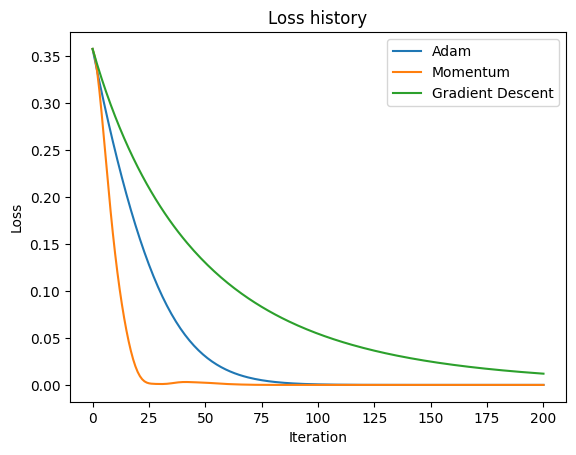

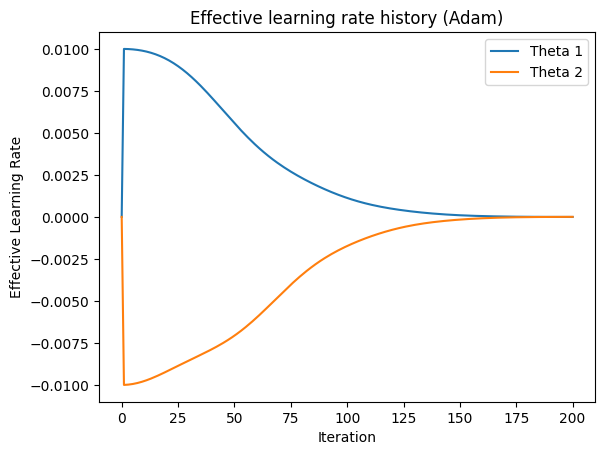

In [79]:
def adam_gradient(theta_init, target, lengths, learning_rate=0.01, n_iterations=500, beta1=0.9, beta2=0.999, epsilon=1e-8):
    # Convert to JAX arrays
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    

    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)
    grad_fn = grad_loss_target

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))
    v_history = np.zeros((n_iterations + 1, 2))
    eta_eff_history = np.zeros((n_iterations + 1, 2))

    # Initial values
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))
    v_history[0] = np.array((0.0, 0.0))
    eta_eff_history[0] = np.array((0.0, 0.0))

    v, m = jnp.array((0.0, 0.0)), jnp.array((0.0, 0.0))
    # Optimization loop
    for i in range(n_iterations):
        # Compute gradient
        gradient = grad_fn(theta, lengths_jax, target_jax)
        
        # Update theta using gradient descent rule
        m = beta1*m + (1 - beta1)*gradient
        v = beta2*v + (1- beta2)*(gradient**2)
        m_n = m/(1 - beta1**(i+1))
        v_n = v/(1 - beta2**(i+1))
        theta = theta - learning_rate * (m_n / (jnp.sqrt(v_n) + epsilon))
        
        # Store history
        theta_history[i + 1] = np.array(theta)        
        loss_history[i + 1] = float(loss_fn(theta))        
        ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))
        v_history[i + 1] = np.array(v)
        eta_eff_history[i+1] = learning_rate * (m_n / (jnp.sqrt(v_n) + epsilon))
    
    return theta_history, loss_history, ee_trajectory, v_history, eta_eff_history

theta_init = [2.5, -2.0]
target = jnp.array([0.5, 1.5])
theta_hist, loss_hist, ee_traj, v_hist, eta_hist = adam_gradient(theta_init, target, LENGTHS, learning_rate=0.01, n_iterations=200)
theta_hist2, loss_hist2, ee_traj2, v_hist2 = momentum_gradient(theta_init, target, LENGTHS, learning_rate=0.01, n_iterations=200)
theta_hist3, loss_hist3, ee_traj3 = gradient_descent(theta_init, target, LENGTHS, learning_rate=0.01, n_iterations=200)
plt.figure()
plt.plot(loss_hist)
plt.plot(loss_hist2)
plt.plot(loss_hist3)
plt.legend(['Adam', 'Momentum', 'Gradient Descent'])        
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

plt.plot(eta_hist[:,0], label='Theta 1')
plt.plot(eta_hist[:,1], label='Theta 2')
plt.title('Effective learning rate history (Adam)')
plt.xlabel('Iteration')
plt.ylabel('Effective Learning Rate')
plt.legend()
plt.show()

Q8

Le gradient classique arrive à 0.01 de la cible au bout d'environ 70 itérations.
Pour le gradient avec momentum, c'est environ 15 itérations.
Pour la méthode Adam, c'est environ 30 itérations.

Dans notre cas et avec ces paramètres, on a donc momentum > adam > gradient.
Ici, Adam est "trop prudent" par rapport à la relative simplicité de l'espace d'optimisation. 
Le gradient avec inertie le dépasse donc.


<div class="alert alert-info">
Q9: For the Adam optimizer on the same task, plot the effective per-parameter learning rate ($η_eff = η * m̂_t / (√v̂_t + ε)$) for both $θ₁$ and $θ₂$ over time. Do they receive the same effective learning rate throughout optimization? Explain why this adaptive behavior is useful.</div>

Q9

Au cours du processus d'optimisation, theta1 et theta2 reçoivent un pas d'apprentissage similaire en valeur absolue, qui diminue au fil des itérations. On remarquera que leurs valeurs sont opposées, ce qui signifie que theta1 doit augmenter et theta2 diminuer pour descendre le gradient.
Diminuer le pas d'apprentissage au cours des itérations permet d'assurer une convergence, et d'éviter un phénomène d'oscillations près du minimum.

## Part 3: Gradient-Free Optimization

For this exercise, implement a basic gradient-free algorithm, specifically an evolutionary strategy. Evolution Strategies are a class of gradient-free optimization algorithms inspired by natural evolution. Unlike gradient-based methods that require computing derivatives, ES samples multiple candidate solutions (a "population") around the current solution, evaluates their fitness (objective function value), and moves toward the direction indicated by the better-performing samples. Use the following rules for your ES:

For iteration $t$, with current parameter vector $\theta_t$:
$$
\begin{align}
\epsilon_i &\sim \mathcal{N}(0, I) \quad \text{for } i = 1, \ldots, N \\
\theta_i &= \theta_t + \sigma \epsilon_i \\
F_i &= -L(\theta_i) \quad \text{(fitness = negative loss)} \\
\theta_{t+1} &= \theta_t + \alpha \frac{1}{N} \sum_{i=1}^{N} F_i \epsilon_i
\end{align}
$$

where $N$ is the population size, $\sigma$ is the exploration noise (standard deviation), $\alpha$ is the learning rate, and $\epsilon_i$ are the perturbation vectors.

<div class="alert alert-info">
    Q10: Run this ES with population sizes $P = [10, 20, 50]$. For each, report: (a) does it reach the target successfully? (b) how many iterations does it take? (c) total number of function evaluations ($P$ × iterations). What trend do you observe with increasing population size?</div>

Réponse question 10: a. Oui avec 200 itérations par exemple b. et c. Il semble qu'en relançant plusieurs le code on remarque qu'il nécessite moins d'itérations pour converger avec une population plus grande mais il nécessite plus d'évaluations pour converger avec une population plus grande. Par exemple, on obtiens la convergence en 182, 134 et 123 itérations pour respectivement une population de 10, 20 et 50. Tandis que le nombre d'itérations est respectivement 1820, 2680 et 6150. Une dernière remarque semble que la distance à la cible soit de moins en moins bruitée avec une hausse de la population.

In [80]:
def gradient_descent_evolution_strategy(theta_init: np.ndarray, 
                     target: np.ndarray,
                     lengths: np.ndarray,
                     learning_rate: float = 0.01,
                     n_iterations: int = 200,
                     population: int = 10,
                     sigma: float=0.1,
                     accuracy: float=0.01) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Convert to JAX arrays
    theta_p = np.array(theta_init)
    lengths_jax = np.array(lengths)
    target_jax = np.array(target)
    

    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))
    
    # Initial values
    theta_history[0] = np.array(theta_p)
    loss_history[0] = float(loss_fn(theta_p))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta_p, lengths_jax))
    distances = []
    # Optimization loop
    for i in range(n_iterations):
        
        epsilons= np.random.normal(0,1,(population,2))
        losses=np.zeros(population)
        for j in range(population):
            losses[j]=loss_fn(theta_p + sigma*epsilons[j])

        fitness=-losses
        grad_estimate = np.dot(fitness, epsilons) / population
        theta = theta_p + learning_rate * grad_estimate
        theta_p=theta
        
        # Store history
        theta_history[i + 1] = np.array(theta)        
        loss_history[i + 1] = float(loss_fn(theta))        
        ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))
        # Calculer la distance euclidienne entre la position actuelle et la cible
        dist_to_target = np.linalg.norm(ee_trajectory[i + 1] - target)
        distances.append(dist_to_target)
        # Vérifier si la distance est inférieure à l'accuracy
        if dist_to_target < accuracy:
            print(f"Converged in {i+1} iterations.")
            plt.figure()
            plt.plot(distances, marker='o')
            plt.xlabel("Iteration")
            plt.ylabel("Distance to target")
            plt.title("Évolution de la distance vers la cible")
            plt.grid(True)
            plt.show()
            return theta_history[:i+2], loss_history[:i+2], ee_trajectory[:i+2],i

    plt.figure()
    plt.plot(distances, marker='o')
    plt.xlabel("Iteration")
    plt.ylabel("Distance to target")
    plt.title("Évolution de la distance vers la cible")
    plt.grid(True)
    plt.show()
    return theta_history, loss_history, ee_trajectory,i

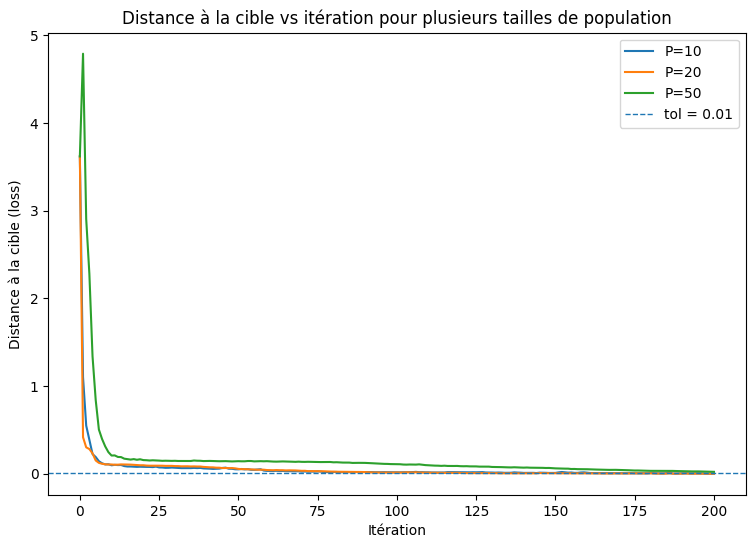

Résumé des résultats (tol = 0.01 ):
P	Reached	Iterations	Total evaluations
10	True	140	1400
20	True	120	2400
50	False	>=200	10000


In [81]:
import numpy as np
import jax.numpy as jnp
from jax import vmap, random
import matplotlib.pyplot as plt

 
def evolutionary_strategy(theta_init: np.ndarray,
                          target: np.ndarray,
                          lengths: np.ndarray,
                          learning_rate: float = 0.2,     # learning rate
                          sigma: float = 0.1,     # exploration noise
                          population : int = 50,            # population size
                          n_iterations: int = 300):  #add accuracy ?


 
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax) # function with only one argument


 
    # stockage
    theta_history = np.zeros((n_iterations + 1, len(theta_init)))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))


 
    # init
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))



 
    for t in range(n_iterations):


 
        eps = np.random.normal(0,1,(population,2))
        thetas_candidates = theta + sigma * eps
        losses_list = []
        for i in range(population):
            losses_list.append(float(loss_fn(thetas_candidates[i])))
        losses = jnp.array(losses_list)
        fitness = -losses
        grad_est = (1.0 / population) * jnp.dot(fitness, eps)
        theta = theta + learning_rate * grad_est


 
        theta_history[t + 1] = np.array(theta)
        loss_history[t + 1] = float(loss_fn(theta))
        ee_trajectory[t + 1] = np.array(forward_kinematics_jax(theta, lengths_jax)) # pour plot ensuite


 
    return theta_history, loss_history, ee_trajectory


 

# Paramètres du bras et de la cible
theta_init = np.array([0.1, 0.1])
target = np.array([0.5, 1.5]) # cible idem que question 6
lengths = np.array([1.0, 1.0])

populations = [10, 20, 50]
n_iterations = 200
learning_rate = 0.3
sigma = 0.1
 
# Critère d'atteinte : distance <= tol
tol = 0.01 #comme dans la question 8

results = {}  # stocke loss_history et autres par population
 
for P in populations:
    theta_hist, loss_hist, ee_traj = evolutionary_strategy(
        theta_init=theta_init,
        target=target,
        lengths=lengths,
        learning_rate=learning_rate,
        sigma=sigma,
        population=P,
        n_iterations=n_iterations
    )
    # déterminer la première itération qui sastifait la tolérance 
    reached_idx = None
    for idx, val in enumerate(loss_hist):
        if val <= tol:
            reached_idx = idx
            break
 
    if reached_idx is None:
        reached = False
        iterations_to_reach = None
        total_evals = P * n_iterations
    else:
        reached = True
        iterations_to_reach = reached_idx
        total_evals = P * iterations_to_reach
    #resultats pour une population donnée, certains seront utilisés pour debug
    results[P] = {
        "loss_hist": loss_hist,
        "ee_traj": ee_traj,
        "theta_hist": theta_hist,
        "reached": reached,
        "iterations_to_reach": iterations_to_reach,
        "total_evals": total_evals
    }

#   affichage des courbes de loss
plt.figure(figsize=(9, 6))
for P in populations:
    loss_hist = results[P]["loss_hist"]
    label = f"P={P}"
    plt.plot(loss_hist, label=label)
plt.axhline(tol, linestyle='--', linewidth=1, label=f"tol = {tol}")
plt.xlabel("Itération")
plt.ylabel("Distance à la cible (loss)")
plt.title("Distance à la cible vs itération pour plusieurs tailles de population")
plt.legend()
plt.show()

print("Résumé des résultats (tol =", tol, "):")
print("P\tReached\tIterations\tTotal evaluations")
 
for P in populations:
    r = results[P]
    iterations = r["iterations_to_reach"] if r["reached"] else f">={n_iterations}"
    print(P, r["reached"], iterations, r["total_evals"], sep="\t")


<div class="alert alert-info">
Q11: ES doesn't use gradients, so it evaluates the loss N times per iteration while SGD evaluates it once plus one gradient computation. For a successful run of each method, count total loss function evaluations. Which is more sample-efficient? Despite this, describe one scenario where ES might still be preferred over gradient-based methods.</div>

Réponse question 11 : Pour l'algorithme ES, on a (nombre de candidats x nombre d'itérations) évaluations de la loss. Tandis que pour l'algorithme SGD, nous avons "nombre d'itérations" d'évaluations de la loss fonction. Donc ES consomme beaucoup plus d'évaluations pour un nombre d'itérations données. On peut en conclure que  SGD est plus sample-efficient. ES peut être meilleure que les méthodes basées sur le gradient seulement, notamment si la fonction est non-différentiable ou très "bruitée", si le gradient est trop lourd à calculer ou bien encore pour éviter les minimax globaux.

Pour la méthode ES : N+1 fois par itération
Pour la méthode SGD : 2 fois par itération
Etant donné que en l'état la méthode ES ne converge pas, il n'est pas possible de comparer l'efficacité des deux méthodes. A priori, ES reste moins efficace que SGD, mais a l'avantage de ne pas nécessiter de calcul de gradient de la fonction boîte noire, et se montre généralement plus robuste même avec bruit élevé..

## Part 4: Trajectory Optimization - Optimizing Sequences

So far, we've only optimized the **final configuration** of the robot arm - finding joint angles that place the end-effector at the target. However, in real robotics, we often care about the **entire motion path**. A robot might reach the target, but if it does so with jerky, energy-intensive movements, the solution isn't practical.

In this section, you'll optimize a **trajectory** - a sequence of joint angles over time - to reach the target while minimizing energy consumption and ensuring smooth motion.

### Trajectory Representation

Instead of optimizing $\theta \in \mathbb{R}^2$, we now optimize:
$$\Theta = [\theta_0, \theta_1, \ldots, \theta_T] \in \mathbb{R}^{T \times 2}$$

where $T$ is the number of timesteps (e.g., $T=20$).

### Multi-Objective Loss Function

We balance three competing objectives:

$$L_{total}(\Theta) = L_{target} + \lambda_{energy} L_{energy} + \lambda_{smooth} L_{smooth}$$

where:
- **Target reaching**: $L_{target} = \|\text{pos}(\theta_T) - \text{target}\|^2$ (only final position matters)
- **Energy cost**: $L_{energy} = \sum_{t=1}^{T} \|\theta_t - \theta_{t-1}\|^2$ (penalize large joint movements)
- **Smoothness**: $L_{smooth} = \sum_{t=2}^{T} \|(\theta_t - \theta_{t-1}) - (\theta_{t-1} - \theta_{t-2})\|^2$ (penalize acceleration/jerkiness)

The hyperparameters $\lambda_{energy}$ and $\lambda_{smooth}$ control the trade-off between reaching the target quickly versus moving efficiently and smoothly.

In [82]:
# Trajectory Optimization Functions

def loss_trajectory(theta_sequence: jnp.ndarray, 
                   lengths: jnp.ndarray,
                   target: jnp.ndarray,
                   lambda_energy: float = 0.1,
                   lambda_smooth: float = 0.05) -> float:
    """
    Loss for trajectory optimization.
    
    Parameters:
    -----------
    theta_sequence : jnp.ndarray, shape (T, 2)
        Sequence of joint angles over T timesteps
    lengths : jnp.ndarray, shape (2,)
        Link lengths
    target : jnp.ndarray, shape (2,)
        Target position
    lambda_energy : float
        Weight for energy cost
    lambda_smooth : float
        Weight for smoothness cost
    
    Returns:
    --------
    loss : float
        Total loss combining target reaching, energy, and smoothness
    """
    T = theta_sequence.shape[0]
    
    # Target reaching: only final position matters
    final_pos = forward_kinematics_jax(theta_sequence[-1], lengths)
    loss_target = jnp.sum((final_pos - target) ** 2)
    
    # Energy cost: sum of squared velocities (joint movements)
    velocities = theta_sequence[1:] - theta_sequence[:-1]  # Shape: (T-1, 2)
    loss_energy = jnp.sum(velocities ** 2)
    
    # Smoothness cost: sum of squared accelerations
    accelerations = velocities[1:] - velocities[:-1]  # Shape: (T-2, 2)
    loss_smooth = jnp.sum(accelerations ** 2)
    
    return loss_target + lambda_energy * loss_energy + lambda_smooth * loss_smooth


# Create gradient function for trajectory optimization
grad_loss_trajectory = jit(grad(loss_trajectory, argnums=0))

In [83]:
def plot_trajectory_sequence(theta_sequence: np.ndarray,
                             lengths: np.ndarray,
                             target: np.ndarray = None,
                             title: str = "Arm Trajectory Over Time"):
    """
    Visualize the robot arm at multiple points along the trajectory.
    
    Parameters:
    -----------
    theta_sequence : np.ndarray, shape (T, 2)
        Sequence of joint angles
    lengths : np.ndarray
        Link lengths
    target : np.ndarray, optional
        Target position
    title : str
        Plot title
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    T = len(theta_sequence)
    colors = plt.cm.viridis(np.linspace(0, 1, T))
    
    # Plot each arm configuration
    for t in range(0, T, max(1, T//10)):  # Show ~10 frames
        points = get_arm_points(theta_sequence[t], lengths)
        alpha = 0.3 + 0.7 * (t / T)  # Fade from transparent to opaque
        ax.plot(points[:, 0], points[:, 1], 'o-', 
               color=colors[t], alpha=alpha, linewidth=2, markersize=4)
    
    # Plot final configuration more prominently
    points_final = get_arm_points(theta_sequence[-1], lengths)
    ax.plot(points_final[:, 0], points_final[:, 1], 'o-', 
           color='red', linewidth=3, markersize=8, label='Final')
    
    # Plot end-effector trajectory
    ee_traj = np.array([forward_kinematics_numpy(theta_sequence[t], lengths) 
                        for t in range(T)])
    ax.plot(ee_traj[:, 0], ee_traj[:, 1], 'b--', 
           linewidth=2, alpha=0.5, label='End-effector path')
    
    # Plot target
    if target is not None:
        ax.plot(target[0], target[1], 'g*', markersize=20, label='Target')
    
    # Plot base
    ax.plot(0, 0, 'ks', markersize=12, label='Base')
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.legend()
    
    return fig, ax

In [84]:
def analyze_trajectory_metrics(theta_sequence: np.ndarray):
    """
    Compute and print trajectory quality metrics.
    
    Parameters:
    -----------
    theta_sequence : np.ndarray, shape (T, 2)
        Sequence of joint angles
    """
    velocities = np.diff(theta_sequence, axis=0)
    accelerations = np.diff(velocities, axis=0)
    
    # Compute metrics
    total_movement = np.sum(np.abs(velocities))
    max_velocity = np.max(np.linalg.norm(velocities, axis=1))
    max_acceleration = np.max(np.linalg.norm(accelerations, axis=1))
    smoothness = np.sum(accelerations ** 2)  # Lower is smoother
    
    print("Trajectory Metrics:")
    print(f"  Total joint movement: {total_movement:.4f} radians")
    print(f"  Max velocity: {max_velocity:.4f} rad/timestep")
    print(f"  Max acceleration: {max_acceleration:.4f} rad/timestep²")
    print(f"  Smoothness cost: {smoothness:.4f} (lower is better)")

In [97]:
# Test trajectory optimization with gradient descent
def gradient_descent_trajectory(theta0: np.ndarray,
                               target: np.ndarray,
                               lengths: np.ndarray,
                               T: int = 20,
                               learning_rate: float = 0.01,
                               n_iterations: int = 1000,
                               lambda_energy: float = 0.1,
                               lambda_smooth: float = 0.05,
                               grad_fun: str = "SGD") -> Tuple[np.ndarray, np.ndarray]:
    # Initialize trajectory: linear interpolation from init to a guess
    theta_init = theta0.copy()
    target_angles = theta_init + 0.5  # Simple guess for final angles
    theta_sequence = jnp.array([
        theta_init + (target_angles - theta_init) * t / (T - 1)
        for t in range(T)
    ])
    
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    
    loss_history = []
    
    for iteration in range(n_iterations):
        # Compute loss and gradient
        loss_val = loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                   lambda_energy, lambda_smooth)
        gradient = grad_loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                       lambda_energy, lambda_smooth)
        
        # Update trajectory
        if grad_fun == "SGD":
            theta_sequence = theta_sequence - learning_rate * gradient
        elif grad_fun == "Momentum":
            if iteration == 0:
                v = jnp.zeros_like(theta_sequence)
            v = 0.9 * v + learning_rate * gradient
            theta_sequence = theta_sequence - v
        elif grad_fun == "Adam":
            if iteration == 0:
                m = jnp.zeros_like(theta_sequence)
                v = jnp.zeros_like(theta_sequence)
            m = 0.9 * m + 0.1 * gradient
            v = 0.999 * v + 0.001 * (gradient ** 2)
            m_hat = m / (1 - 0.9 ** (iteration + 1))
            v_hat = v / (1 - 0.999 ** (iteration + 1))
            theta_sequence = theta_sequence - learning_rate * (m_hat / (jnp.sqrt(v_hat) + 1e-8))
        
        # Figer le départ
        theta_sequence = theta_sequence.at[0].set(theta0)
        loss_history.append(float(loss_val))
        
        if iteration % 100 == 0:
            print(f"Iteration {iteration}: Loss = {loss_val:.6f}")
    
    return np.array(theta_sequence), np.array(loss_history)

In [86]:
# Example usage
print("="*60)
print("Testing Trajectory Optimization")
print("="*60)

theta_init = np.array([0.1, 0.1])
target = np.array([1.0, 1.5])
T = 20

print(f"\nOptimizing trajectory with T={T} timesteps")
print(f"Initial configuration: {theta_init}")
print(f"Target position: {target}\n")

theta_traj, loss_hist = gradient_descent_trajectory(
    theta_init, target, LENGTHS,
    T=T, learning_rate=0.01, n_iterations=1000,
    lambda_energy=0.1, lambda_smooth=0.05
)

Testing Trajectory Optimization

Optimizing trajectory with T=20 timesteps
Initial configuration: [0.1 0.1]
Target position: [1.  1.5]

Iteration 0: Loss = 0.037871
Iteration 100: Loss = 0.011086
Iteration 200: Loss = 0.009691
Iteration 300: Loss = 0.008755
Iteration 400: Loss = 0.008082
Iteration 500: Loss = 0.007578
Iteration 600: Loss = 0.007187
Iteration 700: Loss = 0.006876
Iteration 800: Loss = 0.006623
Iteration 900: Loss = 0.006412


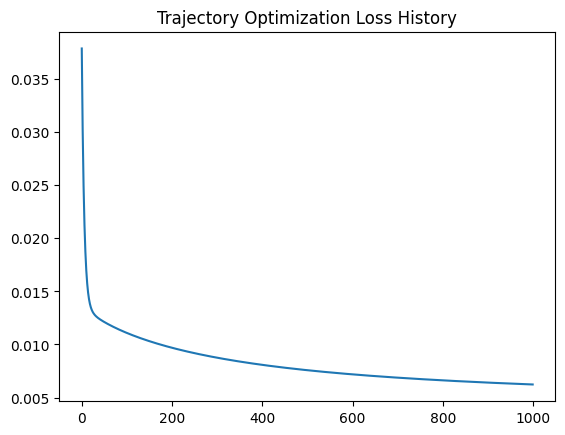

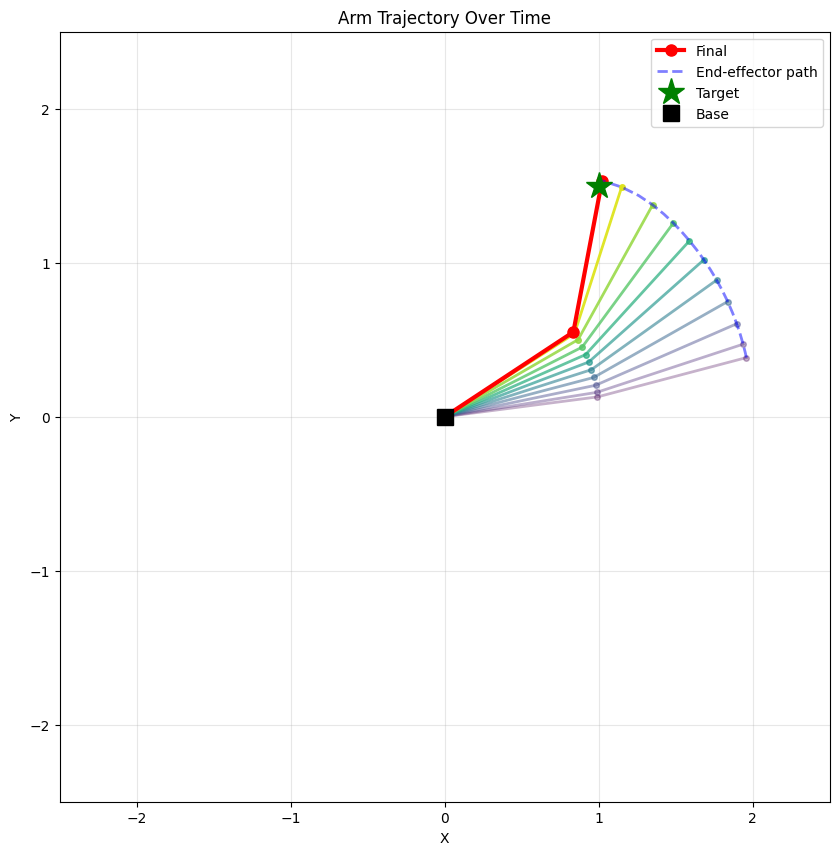

Trajectory Metrics:
  Total joint movement: 1.1252 radians
  Max velocity: 0.1116 rad/timestep
  Max acceleration: 0.0265 rad/timestep²
  Smoothness cost: 0.0019 (lower is better)


In [87]:
# Visualize results
plt.figure()
plt.plot(loss_hist)
plt.title('Trajectory Optimization Loss History')
plt.show()

plot_trajectory_sequence(theta_traj, LENGTHS, target)
plt.show()

analyze_trajectory_metrics(theta_traj)

<div class="alert alert-info">
Q12: Run trajectory optimization with three different energy weights: $\lambda_{energy} = [0.01, 0.1, 1.0]$ (keep $\lambda_{smooth}=0.05$ fixed). For each, visualize the resulting trajectory and report the total joint movement (sum of velocity magnitudes). How does increasing the energy penalty affect the motion? Does the arm still reach the target?
</div>

Iteration 0: Loss = 0.473196
Iteration 100: Loss = 0.053968
Iteration 200: Loss = 0.032955
Iteration 300: Loss = 0.020780
Iteration 400: Loss = 0.014254
Iteration 0: Loss = 0.475565
Iteration 100: Loss = 0.067219
Iteration 200: Loss = 0.049671
Iteration 300: Loss = 0.039472
Iteration 400: Loss = 0.033314
Iteration 0: Loss = 0.499249
Iteration 100: Loss = 0.142858
Iteration 200: Loss = 0.127817
Iteration 300: Loss = 0.119235
Iteration 400: Loss = 0.113106
Trajectory Metrics:
  Total joint movement: 1.6535 radians
  Max velocity: 0.4439 rad/timestep
  Max acceleration: 0.2195 rad/timestep²
  Smoothness cost: 0.0793 (lower is better)
Trajectory Metrics:
  Total joint movement: 1.5878 radians
  Max velocity: 0.3195 rad/timestep
  Max acceleration: 0.1162 rad/timestep²
  Smoothness cost: 0.0283 (lower is better)
Trajectory Metrics:
  Total joint movement: 1.3403 radians
  Max velocity: 0.1144 rad/timestep
  Max acceleration: 0.0119 rad/timestep²
  Smoothness cost: 0.0009 (lower is better)


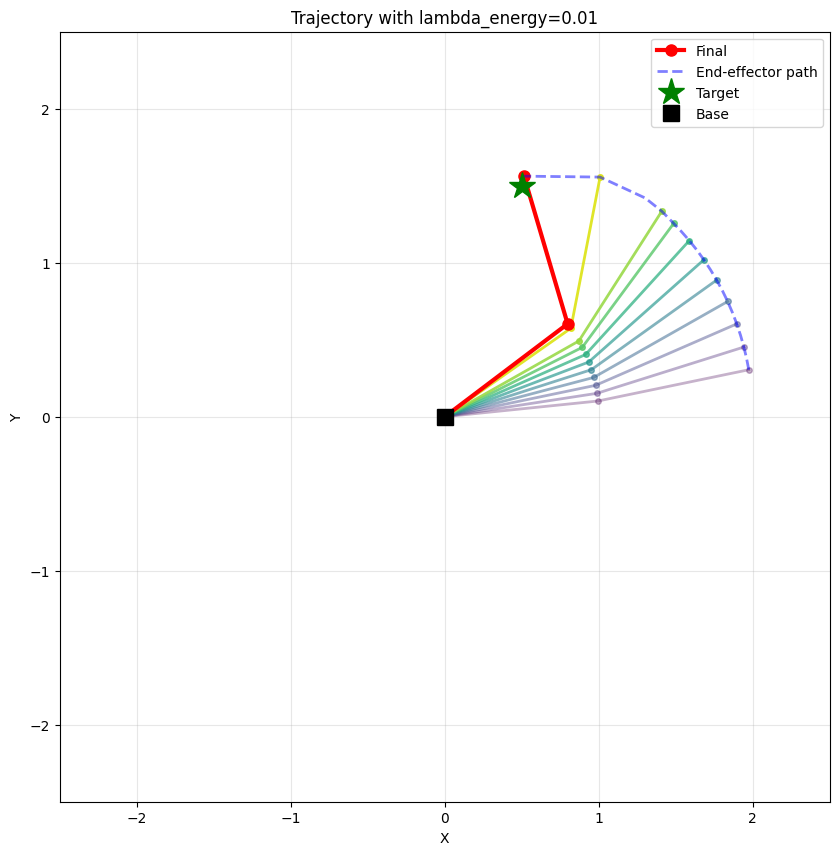

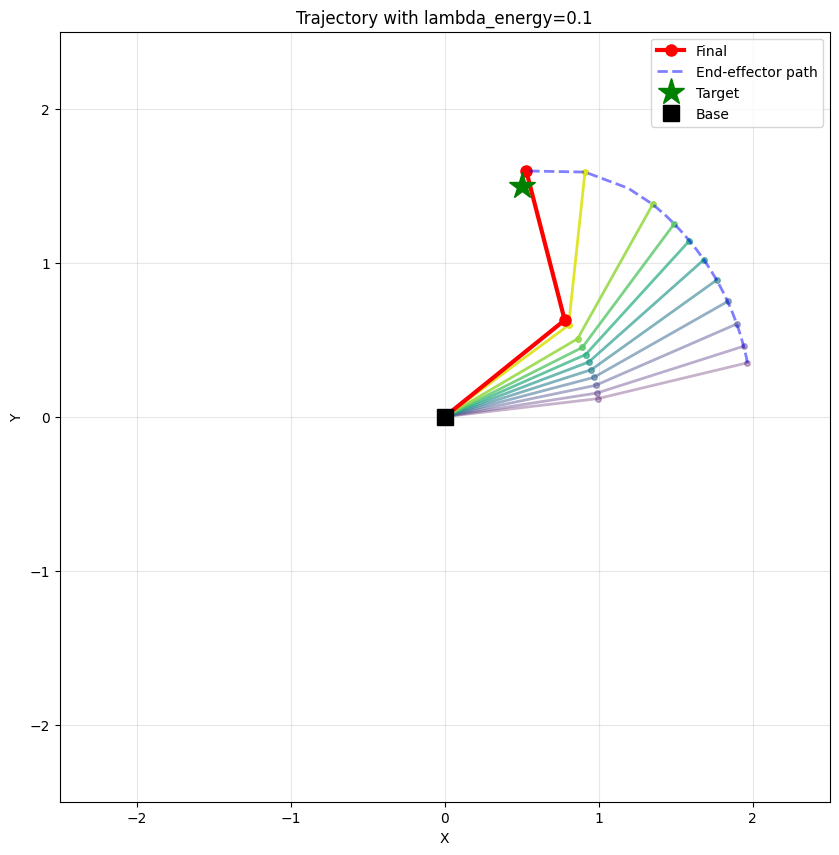

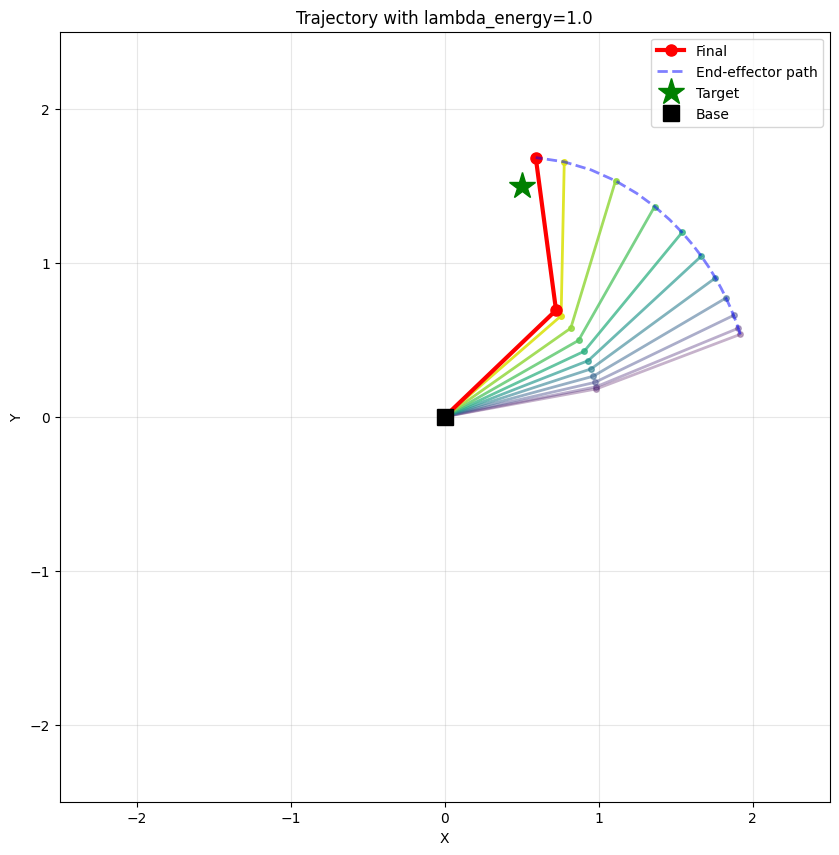

positions finales du bras :  [0.51448774 1.5620754 ] [0.5291666 1.5958166] [0.590719  1.6827828]


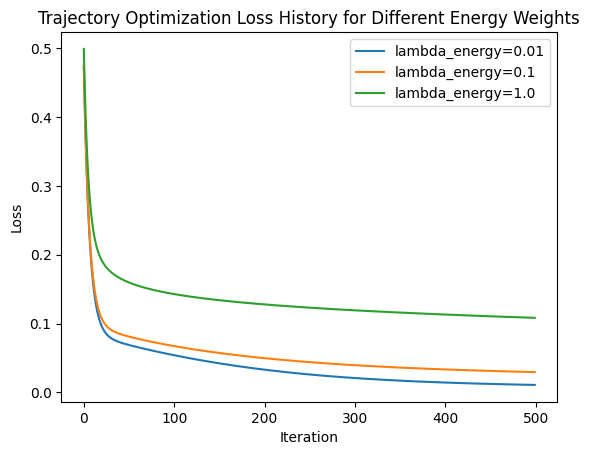

In [95]:
theta_seq1, loss_hist1 = gradient_descent_trajectory(theta_init, target, LENGTHS, T=20, learning_rate=0.01, n_iterations=500, lambda_energy=0.01, lambda_smooth=0.05)
theta_seq2, loss_hist2 = gradient_descent_trajectory(theta_init, target, LENGTHS, T=20, learning_rate=0.01, n_iterations=500, lambda_energy=0.1, lambda_smooth=0.05)
theta_seq3, loss_hist3 = gradient_descent_trajectory(theta_init, target, LENGTHS, T=20, learning_rate=0.01, n_iterations=500, lambda_energy=1.0, lambda_smooth=0.05)
analyze_trajectory_metrics(theta_seq1)
analyze_trajectory_metrics(theta_seq2)
analyze_trajectory_metrics(theta_seq3)
plot_trajectory_sequence(theta_seq1, LENGTHS, target, title="Trajectory with lambda_energy=0.01")
plt.show()
plot_trajectory_sequence(theta_seq2, LENGTHS, target, title="Trajectory with lambda_energy=0.1")
plt.show()
plot_trajectory_sequence(theta_seq3, LENGTHS, target, title="Trajectory with lambda_energy=1.0")
plt.show()
print("positions finales du bras : ",forward_kinematics_jax(theta_seq1[-1], LENGTHS), forward_kinematics_jax(theta_seq2[-1], LENGTHS), forward_kinematics_jax(theta_seq3[-1], LENGTHS))
plt.figure()
plt.plot(loss_hist1, label='lambda_energy=0.01')
plt.plot(loss_hist2, label='lambda_energy=0.1')
plt.plot(loss_hist3, label='lambda_energy=1.0')
plt.title('Trajectory Optimization Loss History for Different Energy Weights')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

Q12

En augmentant la pénalité d'énergie, on rend le mouvement plus "naturel" : au lieu d'observer des intervalles de positions identiquement espacés, on se retrouve avec des phases d'accélération et de décélération. Dans tous les cas, le bras atteint la cible.

<div class="alert alert-info">
Q13: Compare trajectory optimization using SGD with Momentum vs Adam. Use $T=20$, $\lambda_{energy}=0.1$, $\lambda_{smooth}=0.05$. Which converges faster? Plot both trajectories side-by-side. Do they find qualitatively different solutions (different motion strategies)?
</div>

Iteration 0: Loss = 0.475565
Iteration 100: Loss = 0.067263
Iteration 200: Loss = 0.049750
Iteration 300: Loss = 0.039578
Iteration 400: Loss = 0.033445
Iteration 0: Loss = 0.475565
Iteration 100: Loss = 0.021721
Iteration 200: Loss = 0.016813
Iteration 300: Loss = 0.014808
Iteration 400: Loss = 0.013642
Iteration 0: Loss = 0.475565
Iteration 100: Loss = 0.033596
Iteration 200: Loss = 0.010761
Iteration 300: Loss = 0.009023
Iteration 400: Loss = 0.009001


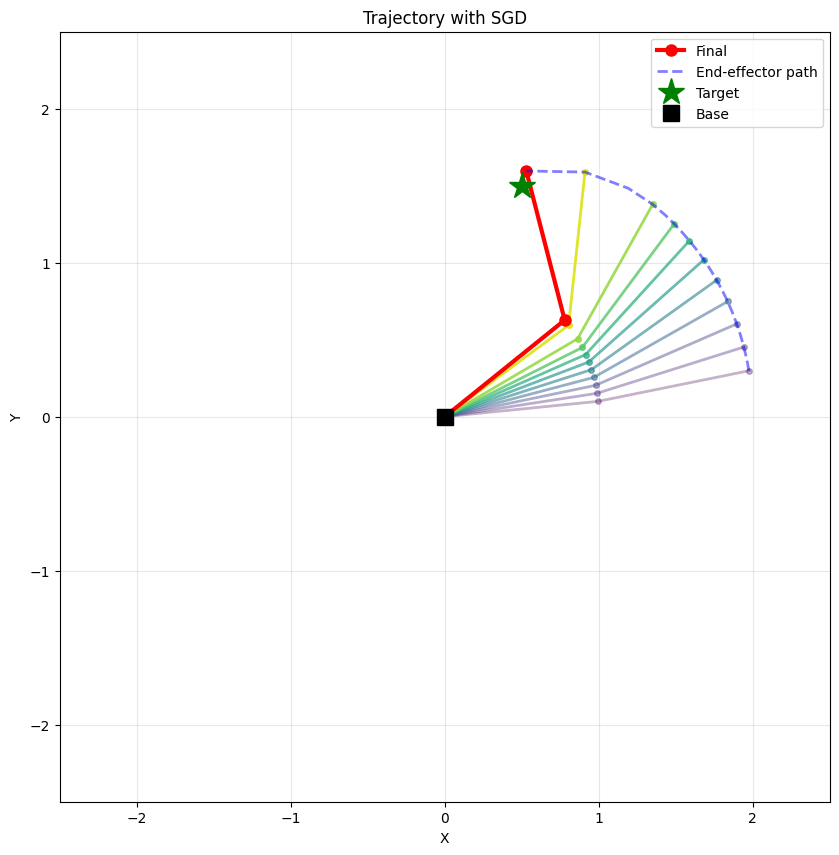

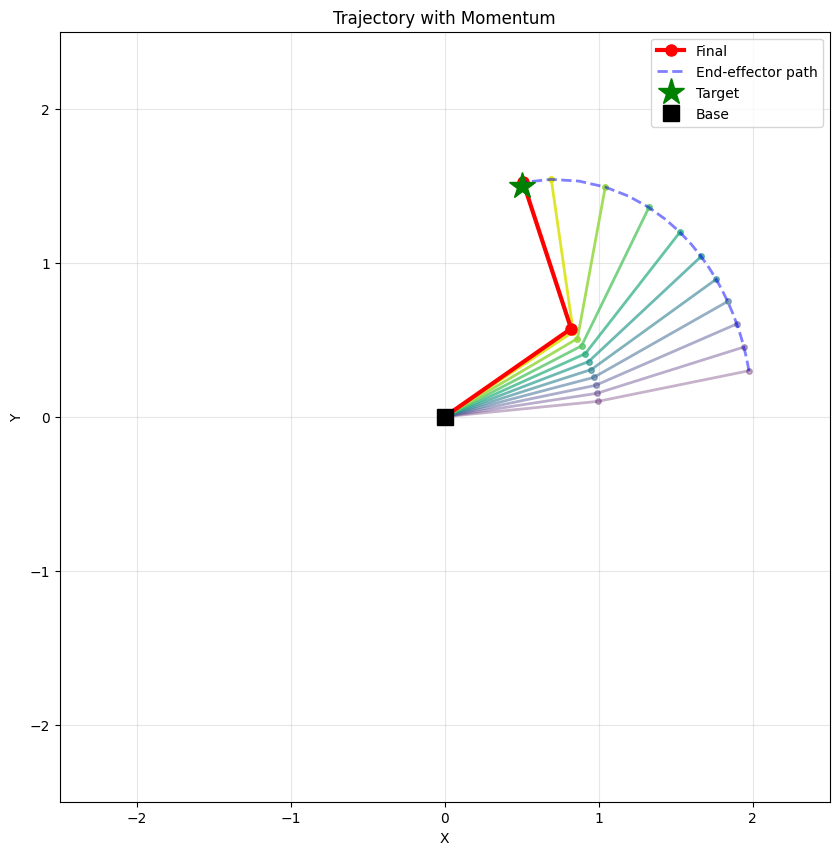

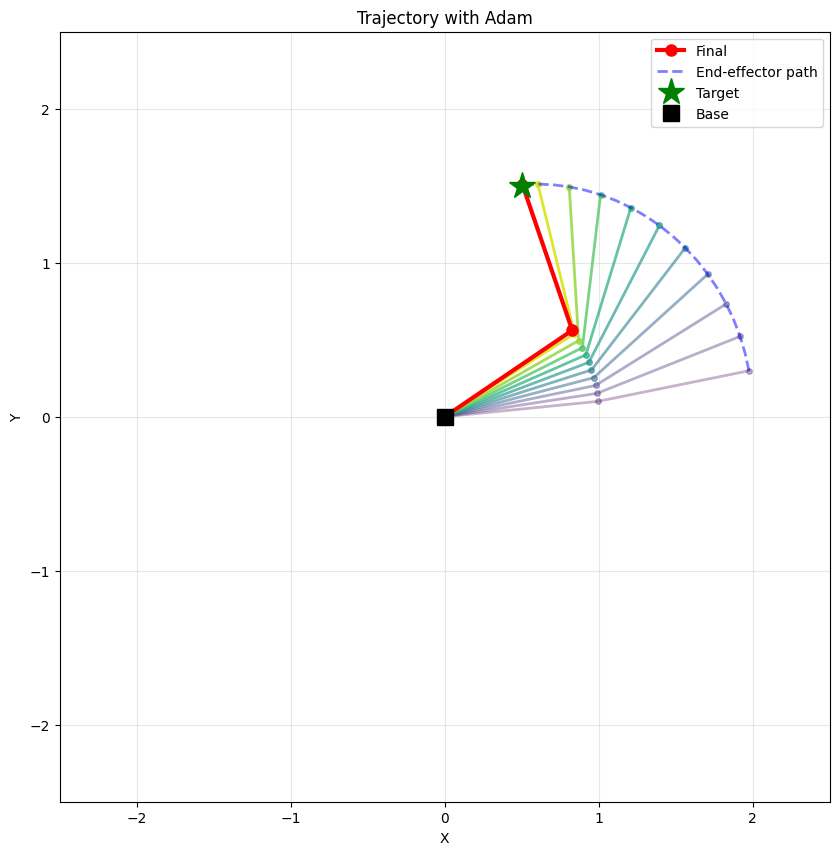

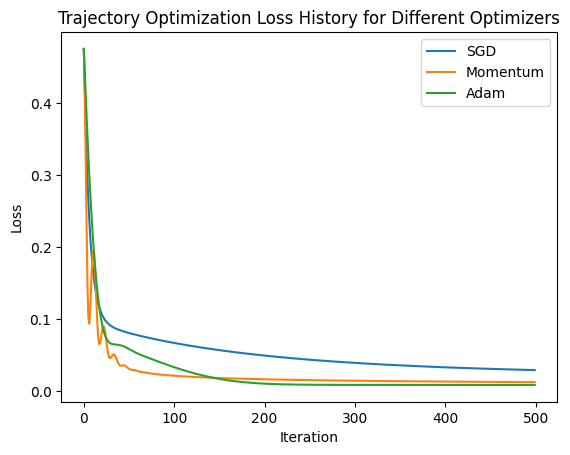

In [98]:
theta_seq1, loss_hist1 = gradient_descent_trajectory(theta_init, target, LENGTHS, T=20, learning_rate=0.01, n_iterations=500, lambda_energy=0.1, lambda_smooth=0.05, grad_fun="SGD")
theta_seq2, loss_hist2 = gradient_descent_trajectory(theta_init, target, LENGTHS, T=20, learning_rate=0.01, n_iterations=500, lambda_energy=0.1, lambda_smooth=0.05, grad_fun="Momentum")
theta_seq3, loss_hist3 = gradient_descent_trajectory(theta_init, target, LENGTHS, T=20, learning_rate=0.01, n_iterations=500, lambda_energy=0.1, lambda_smooth=0.1, grad_fun="Adam")
plot_trajectory_sequence(theta_seq1, LENGTHS, target, title="Trajectory with SGD")
plot_trajectory_sequence(theta_seq2, LENGTHS, target, title="Trajectory with Momentum")
plot_trajectory_sequence(theta_seq3, LENGTHS, target, title="Trajectory with Adam")
plt.show()
plt.plot(loss_hist1, label='SGD')
plt.plot(loss_hist2, label='Momentum')
plt.plot(loss_hist3, label='Adam')
plt.title('Trajectory Optimization Loss History for Different Optimizers')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

Q13

Cette fois, le Adam converge plus rapidement que les deux autres. Qualitativement, les solutions de trajectoire trouvées sont quualitativement les mêmes. On notera que le SGD converge vers une solution moins proche de l'objectif que les deux autres.

<div class="alert alert-info">
Q14: The trajectory optimization problem has $T \times 2$ parameters (40 parameters for $T=20$). This is similar to optimizing a small neural network. Based on your experiments, which optimizer (GD, Momentum, Adam) would you recommend for optimizing trajectories? How might your answer change if $T=100$ (200 parameters)?
</div>

Avec peu de paramètres, Adam est le meilleur optimisateur de trajectoire, c'est donc celui que je choisirais.
Avec plus de paramètres, étant donné que :
- les trois optimisateurs font appel le même nombre de fois à la fonction loss par itération, donc à coût identique par itération 
- avec très peu d'itérations, Momentum semble être le plus performant

C'est donc l'optimisateur momentum que je choisirai, qui assure de meilleur résultats avec un faible nombre d'itérations. A noter que la différence avec Adam n'est pas extrêmement grande.

<div class="alert alert-info">
Q15: Gradient-free methods can also optimize trajectories! However, with $T \times 2$ parameters, the search space becomes much larger. Implement ES for trajectory optimization. Use a smaller population size initially (N=10) and $T=10$ timesteps to keep computation manageable. Compare sample efficiency (total function evaluations) with Adam. When might ES be preferred despite being less sample-efficient?
</div>

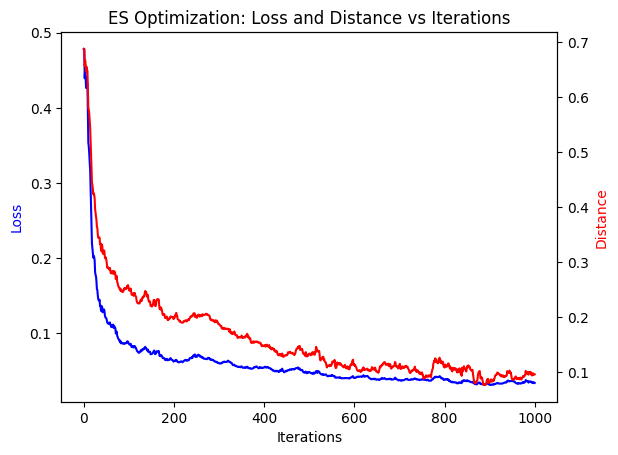

In [90]:

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt



 
def evolutionary_strategy_trajectory(theta_init: np.ndarray,
                                     target: np.ndarray,
                                     lengths: np.ndarray,
                                     lambda_energy: float = 0.1,
                                     lambda_smooth: float = 0.05,
                                     learning_rate: float = 0.1,  # learning rate
                                     sigma: float = 0.1,  # exploration noise
                                     population: int = 10,  # population size
                                     n_iterations: int = 1000,
                                     T: int = 10):  # add accuracy ?


 
    target_angles = theta_init + 0.5  # ok
    theta_sequence_init = jnp.array([
        theta_init + (target_angles - theta_init) * t / (T - 1)
        for t in range(T)
    ]) # ok


 
    lengths_jax = jnp.array(lengths) # ok 
    target_jax = jnp.array(target) # ok 


 
    loss_fn = lambda th_seq: loss_trajectory(th_seq, lengths_jax, target_jax, lambda_energy, lambda_smooth) # ok peut etre de l'autre maniere
    
    # Stockage
    theta_history = np.zeros((n_iterations + 1, T, 2)) # semble identique à gradient_descent à T près
    loss_history = np.zeros(n_iterations + 1) # semble identique à gradient_descent
    ee_trajectory = np.zeros((n_iterations + 1, 2)) # semble identique à gradient_descent


 
    # Init, 
    theta_history[0] = np.array(theta_sequence_init) # semble identique à gradient_descent
    loss_history[0] = float(loss_fn(theta_sequence_init)) # semble identique à gradient_descent
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta_sequence_init[-1], lengths_jax)) # semble identique à gradient_descent à "[-1]" 
 
    for t in range(n_iterations):


 
        eps = np.random.normal(0, 1, (population, T, 2)) # ok
        thetas_candidates = np.empty((population, T, 2)) # ok 
        for i in range(population):
            thetas_candidates[i] = theta_sequence_init + sigma * eps[i] # ok
        losses_list = []


 
        for i in range(population):
            losses_list.append(float(loss_fn(jnp.array(thetas_candidates[i]))))


 
        losses = jnp.array(losses_list)
        fitness = -losses
        grad_est = jnp.zeros((T, 2))
        for i in range(population):
            grad_est += fitness[i] * eps[i]
        grad_est = (1.0 / population) * grad_est
        theta_sequence_init = theta_sequence_init + learning_rate * grad_est


 
        theta_history[t + 1] = np.array(theta_sequence_init)
        loss_history[t + 1] = float(loss_fn(theta_sequence_init))
        ee_trajectory[t + 1] = np.array(forward_kinematics_jax(theta_sequence_init[-1], lengths_jax))


 
    return theta_history, loss_history, ee_trajectory


 
theta_init = np.array([0.1, 0.1])
target = np.array([0.5, 1.5]) # cible idem que question 6
lengths = np.array([1.0, 1.0])
T = 10


 
_, loss_history, ee_trajectory = evolutionary_strategy_trajectory(
    theta_init, target, lengths, population=10, n_iterations=1000, sigma=0.1, learning_rate=0.05, T=10)


 
# calcul distance 
distance_history = np.linalg.norm(ee_trajectory - target, axis=1)


 
# affchage
fig, ax1 = plt.subplots()
ax1.plot(loss_history, 'b-', label='Loss')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Loss', color='b')
ax2 = ax1.twinx()
ax2.plot(distance_history, 'r-', label='Distance to target')
ax2.set_ylabel('Distance', color='r')
plt.title('ES Optimization: Loss and Distance vs Iterations')
plt.show()



Réponse à la question 15 : 
Pour l'algorithme ES du gradient, nous avons (nombre d'itérations * population * T) itérations, tandis que pour Adam on a (nombre d'itérations * T) itérations. Donc Adam est plus sample-efficient. Tout comme la question 11, ES est préférable quand la fonction loss est pas différentiable, discontinue ou bien bruitée par exemple. Ou bien aussi, pour éviter plus facilement les minimas locaux.
